# Job Listing Analytical Dashboard

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
url = 'https://realpython.github.io/fake-jobs/'

In [3]:
response = requests.get(url)

In [4]:
print(response.status_code)

200


In [5]:
print(response.text[0:1000])

<!DOCTYPE html>
<html>
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>Fake Python</title>
    <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bulma@0.9.2/css/bulma.min.css">
  </head>
  <body>
  <section class="section">
    <div class="container mb-5">
      <h1 class="title is-1">
        Fake Python
      </h1>
      <p class="subtitle is-3">
        Fake Jobs for Your Web Scraping Journey
      </p>
    </div>
    <div class="container">
    <div id="ResultsContainer" class="columns is-multiline">
    <div class="column is-half">
<div class="card">
  <div class="card-content">
    <div class="media">
      <div class="media-left">
        <figure class="image is-48x48">
          <img src="https://files.realpython.com/media/real-python-logo-thumbnail.7f0db70c2ed2.jpg?__no_cf_polish=1" alt="Real Python Logo">
        </figure>
      </div>
      <div class="media-content">
        <h2 class="title is-

In [6]:
soup = BeautifulSoup(response.text, 'html.parser')

In [7]:
print(soup.title.text)

Fake Python


In [13]:
results_container = soup.find(id="ResultsContainer")

job_cards = results_container.find_all("div", class_="card-content")

print( len(job_cards))

100


#### Extract Job Data

In [15]:
import numpy as np

In [16]:
jobs = []

for job in job_cards:
    
    # Job Title
    title_element = job.find("h2", class_="title")
    title = title_element.get_text(strip=True) if title_element else np.nan
    
    # Company
    company_element = job.find("h3", class_="company")
    company = company_element.get_text(strip=True) if company_element else np.nan
    
    # Location
    location_element = job.find("p", class_="location")
    location = location_element.get_text(" ", strip=True) if location_element else np.nan
    
    # Apply Link
    links = job.find_all("a")
    
    apply_link = np.nan
    
    if links:
        for link in links:
            href = link.get("href")
            
            if href:
                apply_link = href
                break
    
    jobs.append({
        "job_title": title,
        "company": company,
        "location": location,
        "apply_link": apply_link
    })

df = pd.DataFrame(jobs)

print("Scraping completed!")
print("Total records:", len(df))

df.head()

Scraping completed!
Total records: 100


,job_title,company,location,apply_link
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",https://www.realpython.com
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",https://www.realpython.com
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",https://www.realpython.com
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",https://www.realpython.com
4,Product manager,Ramirez Inc,"North Jamieview, AP",https://www.realpython.com


#### Add Scraping Date

In [18]:
from datetime import datetime

In [19]:
df["scraped_date"] = datetime.now().strftime("%Y-%m-%d")

df.head()

,job_title,company,location,apply_link,scraped_date
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",https://www.realpython.com,2026-09-15
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",https://www.realpython.com,2026-09-15
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",https://www.realpython.com,2026-09-15
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",https://www.realpython.com,2026-09-15
4,Product manager,Ramirez Inc,"North Jamieview, AP",https://www.realpython.com,2026-09-15


#### Check Dataset Information

In [20]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(100, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   job_title     100 non-null    object
 1   company       100 non-null    object
 2   location      100 non-null    object
 3   apply_link    100 non-null    object
 4   scraped_date  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [21]:
df.head(10)

,job_title,company,location,apply_link,scraped_date
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",https://www.realpython.com,2026-09-15
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",https://www.realpython.com,2026-09-15
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",https://www.realpython.com,2026-09-15
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",https://www.realpython.com,2026-09-15
4,Product manager,Ramirez Inc,"North Jamieview, AP",https://www.realpython.com,2026-09-15
5,Medical technical officer,Rogers-Yates,"Davidville, AP",https://www.realpython.com,2026-09-15
6,Physiological scientist,Kramer-Klein,"South Christopher, AE",https://www.realpython.com,2026-09-15
7,Textile designer,Meyers-Johnson,"Port Jonathan, AE",https://www.realpython.com,2026-09-15
8,Television floor manager,Hughes-Williams,"Osbornetown, AE",https://www.realpython.com,2026-09-15
9,Waste management officer,"Jones, Williams and Villa","Scotttown, AP",https://www.realpython.com,2026-09-15


#### Check the missing values

In [22]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
job_title       0
company         0
location        0
apply_link      0
scraped_date    0
dtype: int64


#### Check Duplicate Records

In [23]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


#### Clean text columns

In [25]:
text_columns = [
    "job_title",
    "company",
    "location"
]

for column in text_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

print("Text cleaning completed.")

Text cleaning completed.


#### Handle missing value

In [26]:
for column in ["job_title", "company", "location"]:
    df[column] = df[column].replace(
        ["nan", "", "None"],
        np.nan
    )

df["job_title"] = df["job_title"].fillna("Unknown")
df["company"] = df["company"].fillna("Unknown")
df["location"] = df["location"].fillna("Unknown")

df["apply_link"] = df["apply_link"].fillna("Not Available")

print("Missing values handled successfully.")

Missing values handled successfully.


#### Extract location state

In [27]:
df["state"] = (
    df["location"]
    .str.split(",")
    .str[-1]
    .str.strip()
)

df[["location", "state"]].head(10)

,location,state
0,"Stewartbury, AA",AA
1,"Christopherville, AA",AA
2,"Port Ericaburgh, AA",AA
3,"East Seanview, AP",AP
4,"North Jamieview, AP",AP
5,"Davidville, AP",AP
6,"South Christopher, AE",AE
7,"Port Jonathan, AE",AE
8,"Osbornetown, AE",AE
9,"Scotttown, AP",AP


### Feature Engineering : Job Category

In [28]:
def categorize_job(title):
    
    title = title.lower()
    
    if any(word in title for word in [
        "python", "software", "developer", "programmer",
        "web", "systems", "engineer", "technical"
    ]):
        return "Technology"
    
    elif any(word in title for word in [
        "scientist", "research", "data", "analyst"
    ]):
        return "Data & Research"
    
    elif any(word in title for word in [
        "manager", "executive", "strategy", "sales"
    ]):
        return "Business & Management"
    
    elif any(word in title for word in [
        "designer", "writer", "editor", "photographer"
    ]):
        return "Creative"
    
    elif any(word in title for word in [
        "nurse", "surgeon", "doctor", "medical",
        "psychologist", "therapist"
    ]):
        return "Healthcare"
    
    else:
        return "Other"


df["job_category"] = df["job_title"].apply(categorize_job)

df[["job_title", "job_category"]].head(20)

,job_title,job_category
0,Senior Python Developer,Technology
1,Energy engineer,Technology
2,Legal executive,Business & Management
3,Fitness centre manager,Business & Management
4,Product manager,Business & Management
5,Medical technical officer,Technology
6,Physiological scientist,Data & Research
7,Textile designer,Creative
8,Television floor manager,Business & Management
9,Waste management officer,Other


#### Job Level

In [29]:
def determine_job_level(title):
    
    title = title.lower()
    
    if any(word in title for word in [
        "entry-level",
        "junior",
        "graduate",
        "trainee"
    ]):
        return "Entry Level"
    
    elif any(word in title for word in [
        "senior",
        "lead",
        "principal",
        "chief"
    ]):
        return "Senior Level"
    
    else:
        return "Mid/General Level"


df["job_level"] = df["job_title"].apply(determine_job_level)

df[["job_title", "job_level"]].head(20)

,job_title,job_level
0,Senior Python Developer,Senior Level
1,Energy engineer,Mid/General Level
2,Legal executive,Mid/General Level
3,Fitness centre manager,Mid/General Level
4,Product manager,Mid/General Level
5,Medical technical officer,Mid/General Level
6,Physiological scientist,Mid/General Level
7,Textile designer,Mid/General Level
8,Television floor manager,Mid/General Level
9,Waste management officer,Mid/General Level


#### Python Job Flag

In [30]:
df["python_related"] = (
    df["job_title"]
    .str.lower()
    .str.contains("python", na=False)
    .astype(int)
)

df[["job_title", "python_related"]].head(20)

,job_title,python_related
0,Senior Python Developer,1
1,Energy engineer,0
2,Legal executive,0
3,Fitness centre manager,0
4,Product manager,0
5,Medical technical officer,0
6,Physiological scientist,0
7,Textile designer,0
8,Television floor manager,0
9,Waste management officer,0


#### Title length

In [31]:
df["title_word_count"] = (
    df["job_title"]
    .str.split()
    .str.len()
)

df["title_character_count"] = (
    df["job_title"]
    .str.len()
)

df[[
    "job_title",
    "title_word_count",
    "title_character_count"
]].head(10)

,job_title,title_word_count,title_character_count
0,Senior Python Developer,3,23
1,Energy engineer,2,15
2,Legal executive,2,15
3,Fitness centre manager,3,22
4,Product manager,2,15
5,Medical technical officer,3,25
6,Physiological scientist,2,23
7,Textile designer,2,16
8,Television floor manager,3,24
9,Waste management officer,3,24


In [32]:
df.head()

,job_title,company,location,apply_link,scraped_date,state,job_category,job_level,python_related,title_word_count,title_character_count
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",https://www.realpython.com,2026-09-15,AA,Technology,Senior Level,1,3,23
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",https://www.realpython.com,2026-09-15,AA,Technology,Mid/General Level,0,2,15
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",https://www.realpython.com,2026-09-15,AA,Business & Management,Mid/General Level,0,2,15
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",https://www.realpython.com,2026-09-15,AP,Business & Management,Mid/General Level,0,3,22
4,Product manager,Ramirez Inc,"North Jamieview, AP",https://www.realpython.com,2026-09-15,AP,Business & Management,Mid/General Level,0,2,15


In [33]:
print(df.columns.tolist())

['job_title', 'company', 'location', 'apply_link', 'scraped_date', 'state', 'job_category', 'job_level', 'python_related', 'title_word_count', 'title_character_count']


In [34]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (100, 11)

Missing Values:
job_title                0
company                  0
location                 0
apply_link               0
scraped_date             0
state                    0
job_category             0
job_level                0
python_related           0
title_word_count         0
title_character_count    0
dtype: int64

Duplicate Rows:
0


In [36]:
df.to_csv(
    "job_listings.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


#### Statistical Summary

In [37]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_title,100,92,Python Programmer (Entry-Level),3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,100,99,Garcia PLC,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,100,100,"Stewartbury, AA",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
apply_link,100,1,https://www.realpython.com,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scraped_date,100,1,2026-09-15,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,100,3,AE,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_category,100,6,Other,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_level,100,3,Mid/General Level,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
python_related,100.0,NaN,NaN,NaN,0.1,0.301511,0.0,0.0,0.0,0.0,1.0
title_word_count,100.0,NaN,NaN,NaN,2.25,0.891883,1.0,2.0,2.0,3.0,6.0


##### Job Category Distribution

In [38]:
category_counts = df["job_category"].value_counts()

print(category_counts)

job_category
Other                    42
Technology               24
Creative                 11
Business & Management     9
Data & Research           8
Healthcare                6
Name: count, dtype: int64


#### Plot Job Categories

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

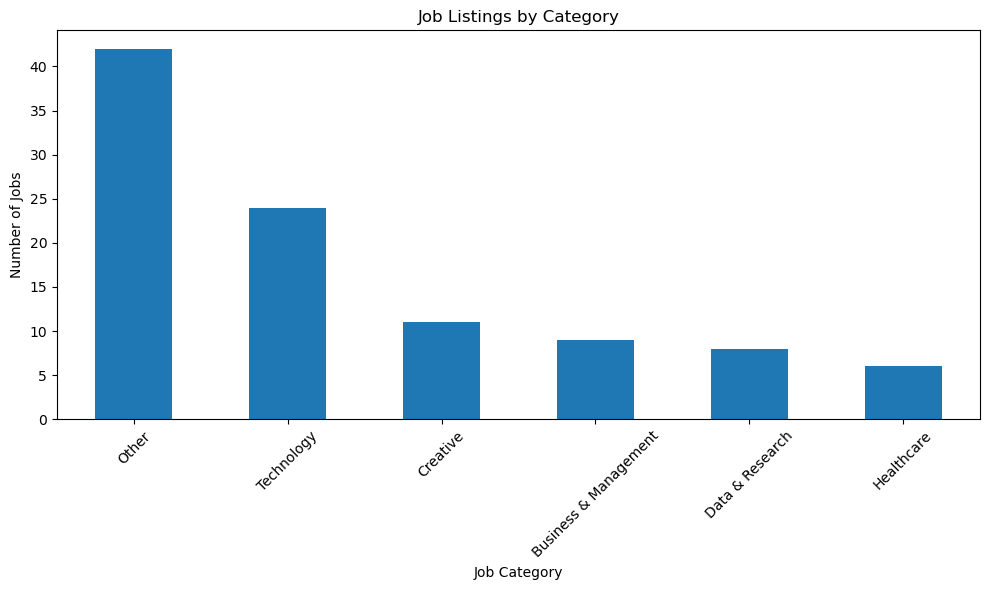

In [41]:
plt.figure(figsize=(10, 6))

category_counts.plot(kind="bar")

plt.title("Job Listings by Category")
plt.xlabel("Job Category")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Job Level Distribution

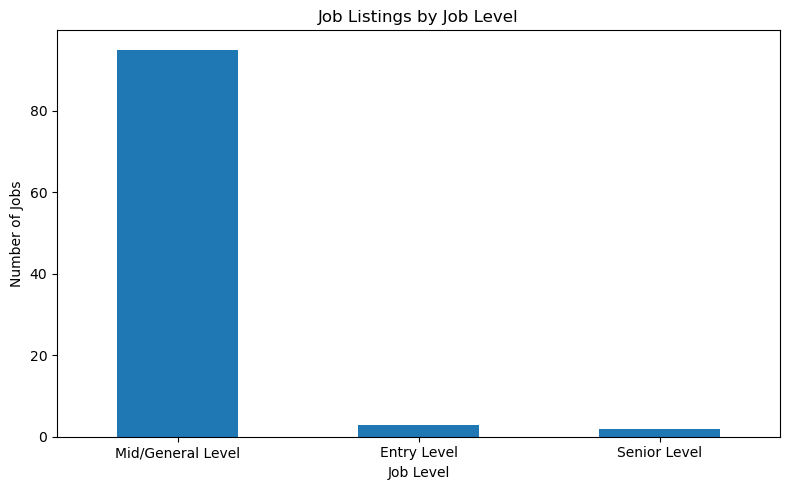

In [43]:
level_counts = df["job_level"].value_counts()

plt.figure(figsize=(8, 5))

level_counts.plot(kind="bar")

plt.title("Job Listings by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### Python Related Jobs

In [42]:
python_jobs = df["python_related"].value_counts()

python_jobs.index = [
    "Not Python Related" if x == 0 else "Python Related"
    for x in python_jobs.index
]

python_jobs

Not Python Related    90
Python Related        10
Name: count, dtype: int64

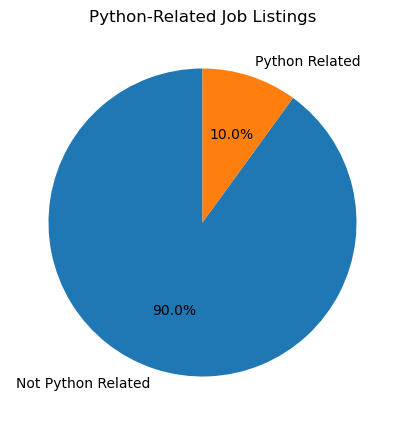

In [44]:
plt.figure(figsize=(7, 5))

python_jobs.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Python-Related Job Listings")

plt.ylabel("")

plt.show()

#### Top Companies

In [45]:
top_companies = (
    df["company"]
    .value_counts()
    .head(10)
)

print(top_companies)

company
Garcia PLC                        2
Payne, Roberts and Davis          1
Smith PLC                         1
Wood Inc                          1
Patton, Haynes and Jones          1
Blankenship, Knight and Powell    1
Jackson, Ali and Mckee            1
Leblanc LLC                       1
Vasquez Ltd                       1
Bailey, Owen and Thompson         1
Name: count, dtype: int64


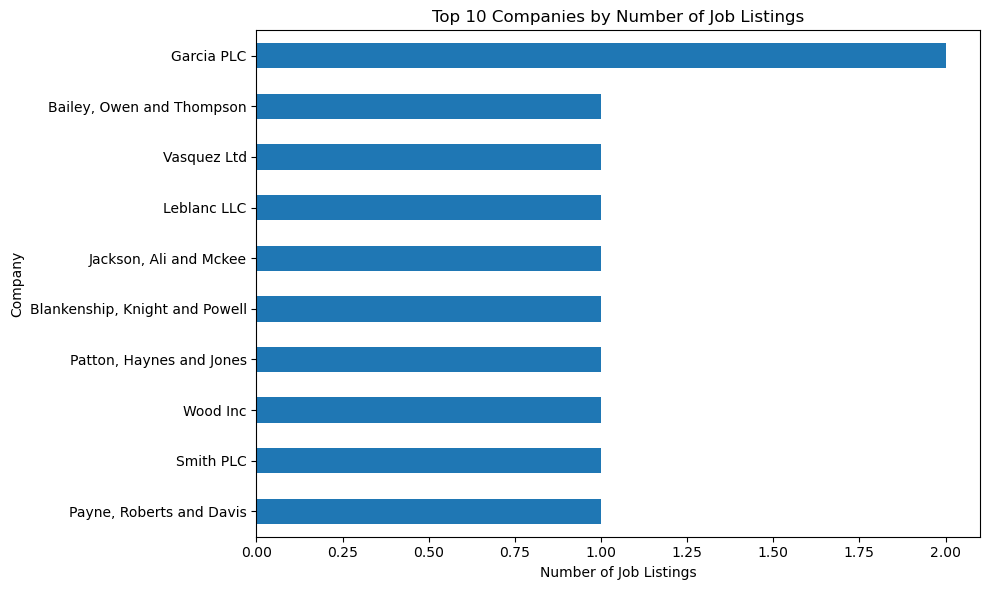

In [46]:
plt.figure(figsize=(10, 6))

top_companies.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Companies by Number of Job Listings")
plt.xlabel("Number of Job Listings")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

#### Top Locations

In [47]:
top_locations = (
    df["location"]
    .value_counts()
    .head(15)
)

print(top_locations)

location
Stewartbury, AA          1
Port Devonville, AE      1
Port Jeremy, AA          1
Lloydton, AP             1
Millsbury, AE            1
New Elizabethside, AA    1
Lake Antonio, AA         1
New Kelly, AP            1
Jamesville, AA           1
Davidside, AA            1
New Jeffrey, AP          1
East Thomas, AE          1
Zacharyport, AA          1
Christopherville, AA     1
Benjaminland, AP         1
Name: count, dtype: int64


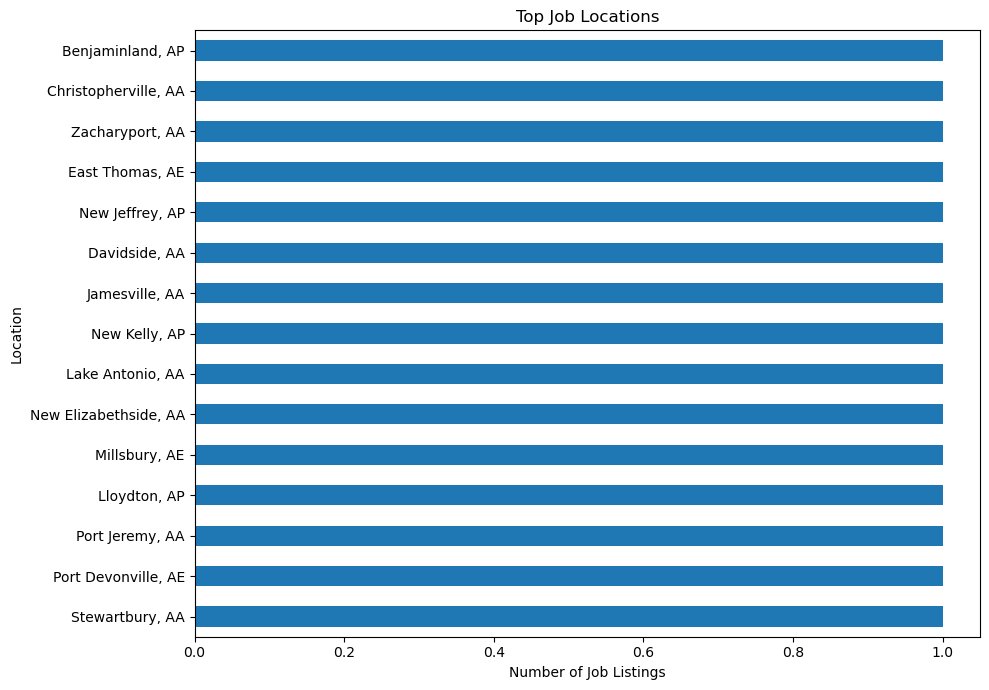

In [48]:
plt.figure(figsize=(10, 7))

top_locations.sort_values().plot(
    kind="barh"
)

plt.title("Top Job Locations")
plt.xlabel("Number of Job Listings")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

#### Job Title Analysis

In [49]:
top_job_titles = (
    df["job_title"]
    .value_counts()
    .head(15)
)

top_job_titles

job_title
Python Programmer (Entry-Level)            3
Legal executive                            2
Manufacturing systems engineer             2
Materials engineer                         2
Futures trader                             2
Software Developer (Python)                2
Back-End Web Developer (Python, Django)    2
Senior Python Developer                    1
Insurance underwriter                      1
Forest/woodland manager                    1
Chartered loss adjuster                    1
Designer, fashion/clothing                 1
Dispensing optician                        1
Producer, radio                            1
Engineer, automotive                       1
Name: count, dtype: int64

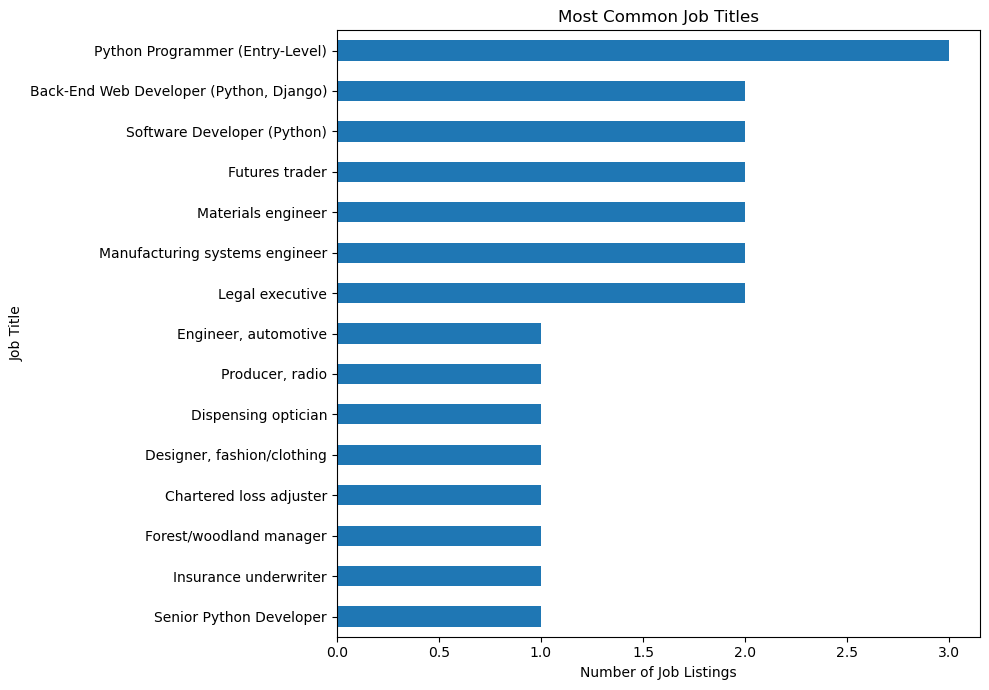

In [50]:
plt.figure(figsize=(10, 7))

top_job_titles.sort_values().plot(
    kind="barh"
)

plt.title("Most Common Job Titles")
plt.xlabel("Number of Job Listings")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

#### Python Job Analysis

In [51]:
python_related_jobs = df[
    df["python_related"] == 1
]

print(
    "Number of Python-related jobs:",
    len(python_related_jobs)
)

python_related_jobs[
    ["job_title", "company", "location"]
].head(20)

Number of Python-related jobs: 10


,job_title,company,location
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA"
10,Software Engineer (Python),Garcia PLC,"Ericberg, AE"
20,Python Programmer (Entry-Level),"Moss, Duncan and Allen","Port Sara, AE"
30,Python Programmer (Entry-Level),Cooper and Sons,"West Victor, AE"
40,Software Developer (Python),Adams-Brewer,"Brockburgh, AE"
50,Python Developer,Rivera and Sons,"East Michaelfort, AA"
60,"Back-End Web Developer (Python, Django)",Stewart-Alexander,"South Kimberly, AA"
70,"Back-End Web Developer (Python, Django)","Jackson, Ali and Mckee","New Elizabethside, AA"
80,Python Programmer (Entry-Level),Mathews Inc,"Robertborough, AP"
90,Software Developer (Python),Moreno-Rodriguez,"Martinezburgh, AE"


In [53]:
python_category = (
    python_related_jobs["job_category"]
    .value_counts()
)

python_category

job_category
Technology    10
Name: count, dtype: int64

#### Correlation Analysis

In [54]:
numeric_columns = [
    "python_related",
    "title_word_count",
    "title_character_count"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,python_related,title_word_count,title_character_count
python_related,1.000000,0.394405,0.374432
title_word_count,0.394405,1.000000,0.804511
title_character_count,0.374432,0.804511,1.000000


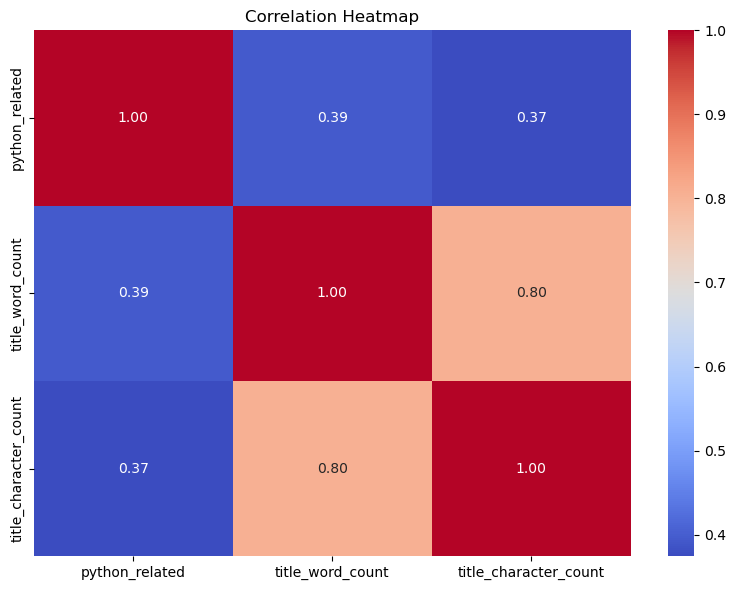

In [55]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

#### One Hot Encoding

In [56]:
one_hot_data = pd.get_dummies(
    df,
    columns=["job_category"],
    prefix="category"
)

print("One-Hot Encoding completed.")

one_hot_data.head()

One-Hot Encoding completed.


,job_title,company,location,apply_link,scraped_date,state,job_level,python_related,title_word_count,title_character_count,category_Business & Management,category_Creative,category_Data & Research,category_Healthcare,category_Other,category_Technology
0,Senior Python Developer,"Payne, Roberts and Davis","Stewartbury, AA",https://www.realpython.com,2026-09-15,AA,Senior Level,1,3,23,False,False,False,False,False,True
1,Energy engineer,Vasquez-Davidson,"Christopherville, AA",https://www.realpython.com,2026-09-15,AA,Mid/General Level,0,2,15,False,False,False,False,False,True
2,Legal executive,"Jackson, Chambers and Levy","Port Ericaburgh, AA",https://www.realpython.com,2026-09-15,AA,Mid/General Level,0,2,15,True,False,False,False,False,False
3,Fitness centre manager,Savage-Bradley,"East Seanview, AP",https://www.realpython.com,2026-09-15,AP,Mid/General Level,0,3,22,True,False,False,False,False,False
4,Product manager,Ramirez Inc,"North Jamieview, AP",https://www.realpython.com,2026-09-15,AP,Mid/General Level,0,2,15,True,False,False,False,False,False


#### Label Encoding

In [58]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [59]:
label_encoder = LabelEncoder()

df["job_level_encoded"] = label_encoder.fit_transform(
    df["job_level"]
)

print("Label Encoding completed.")

print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

Label Encoding completed.
{'Entry Level': 0, 'Mid/General Level': 1, 'Senior Level': 2}


#### Display Encoded data

In [60]:
df[
    [
        "job_title",
        "job_level",
        "job_level_encoded",
        "job_category"
    ]
].head(20)

,job_title,job_level,job_level_encoded,job_category
0,Senior Python Developer,Senior Level,2,Technology
1,Energy engineer,Mid/General Level,1,Technology
2,Legal executive,Mid/General Level,1,Business & Management
3,Fitness centre manager,Mid/General Level,1,Business & Management
4,Product manager,Mid/General Level,1,Business & Management
5,Medical technical officer,Mid/General Level,1,Technology
6,Physiological scientist,Mid/General Level,1,Data & Research
7,Textile designer,Mid/General Level,1,Creative
8,Television floor manager,Mid/General Level,1,Business & Management
9,Waste management officer,Mid/General Level,1,Other


In [61]:
df.to_csv(
    "cleaned_job_listings.csv",
    index=False
)

print("Cleaned dataset saved.")

Cleaned dataset saved.


In [67]:
!streamlit run app.py

^C

      Welcome to Streamlit!

      If you’d like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  

      Welcome to Streamlit!

      If you’d like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  

      Welcome to Streamlit!

      If you’d like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.43.232:8501
  External URL: http://157.45.38.73:8501


      Welcome to Streamlit!

      If you’d like to receive helpful onboarding emails, news, of

In [68]:
report = pd.DataFrame({
    "Metric": [
        "Total Job Listings",
        "Total Companies",
        "Total Locations",
        "Python Related Jobs",
        "Technology Jobs",
        "Data & Research Jobs",
        "Business & Management Jobs",
        "Creative Jobs",
        "Healthcare Jobs"
    ],
    
    "Value": [
        len(df),
        df["company"].nunique(),
        df["location"].nunique(),
        df["python_related"].sum(),
        (df["job_category"] == "Technology").sum(),
        (df["job_category"] == "Data & Research").sum(),
        (df["job_category"] == "Business & Management").sum(),
        (df["job_category"] == "Creative").sum(),
        (df["job_category"] == "Healthcare").sum()
    ]
})

report

,Metric,Value
0,Total Job Listings,100
1,Total Companies,99
2,Total Locations,100
3,Python Related Jobs,10
4,Technology Jobs,24
5,Data & Research Jobs,8
6,Business & Management Jobs,9
7,Creative Jobs,11
8,Healthcare Jobs,6


In [69]:
report.to_csv(
    "job_analysis_report.csv",
    index=False
)

print("Analysis report saved successfully.")

Analysis report saved successfully.


In [71]:
import os

print("app.py exists:", os.path.exists("app.py"))
print("Cleaned dataset exists:", os.path.exists("cleaned_job_listings.csv"))
print("Requirements exists:", os.path.exists("requirements.txt"))
print("README exists:", os.path.exists("README.md"))

app.py exists: True
Cleaned dataset exists: True
Requirements exists: True
README exists: True


In [ ]:
!streamlit run app.py